# 01_building_dedupe_feature_importance_model
a notebook to explore different ML models aimed at measuring the relative importance of attributes (e.g. DOI, title) when establishing whether two records (academic papers, books) are duplicates of one another. 

26/11/25, KH & NL -- start

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

# below are the different classifiers we will try out
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from pathlib import Path

import matplotlib.pyplot as plt
import random
import sys
sys.path.insert(0, '..')
from app.dedupe import Deduper


In [2]:
# modify this to your data path; should contain a csv file with dedupe calculations for n records and n attributes
REPO_DIR = Path.cwd().parent
DATA_PATH = REPO_DIR / 'misc/test_train_compared_261125.csv'
RAW_DATA = REPO_DIR / 'misc/test_data.csv'

In [3]:
test_train_compared_df = pd.read_csv(DATA_PATH)

In [4]:
test_train_compared_df

,Unnamed: 0,id_a,id_b,is_dupe,doi,title,authors,year,journal,pages,abstract,volume,issue
0,0,6,25251,1,1.0,1.000000,1.000000,1.0,1.000000,1.0,0.755385,1.000000,1.0
1,1,17,25280,1,1.0,1.000000,1.000000,1.0,1.000000,1.0,0.964158,1.000000,1.0
2,2,25,25228,1,1.0,1.000000,1.000000,1.0,1.000000,0.0,0.976696,0.696970,0.8
3,3,26,25288,1,1.0,1.000000,1.000000,1.0,1.000000,0.0,0.984689,0.803509,0.0
4,4,36,25271,1,1.0,1.000000,1.000000,1.0,1.000000,0.0,0.979578,0.762963,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68043,68043,3323,45913,0,0.0,0.200000,0.594693,1.0,0.846154,0.0,0.000000,1.000000,0.0
68044,68044,13955,13480,0,0.0,0.230159,0.535837,1.0,0.622222,0.0,0.257487,0.000000,1.0
68045,68045,13319,13351,0,0.0,0.263566,0.359649,1.0,0.535714,0.0,0.270473,0.000000,1.0
68046,68046,2946,4925,0,0.0,0.181818,0.556851,1.0,0.597884,0.0,0.254840,0.000000,1.0


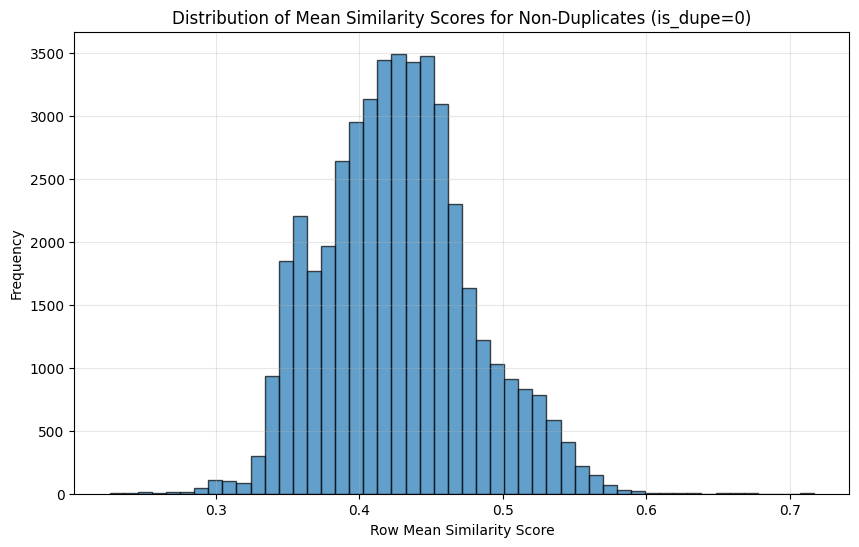

Summary statistics for non-duplicate row means:
count    45359.000000
mean         0.426504
std          0.051775
min          0.225976
25%          0.390175
50%          0.425231
75%          0.457945
max          0.716827
Name: row_mean, dtype: float64


In [5]:

# Create subset where is_dupe==0
non_dupes = test_train_compared_df[test_train_compared_df['is_dupe'] == 0].copy()

# Calculate row means for specified columns
similarity_cols = ['doi', 'title', 'authors', 'year', 'journal', 'pages', 'abstract', 'volume', 'issue']
non_dupes['row_mean'] = non_dupes[similarity_cols].mean(axis=1)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(non_dupes['row_mean'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Row Mean Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Similarity Scores for Non-Duplicates (is_dupe=0)')
plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print(f"Summary statistics for non-duplicate row means:")
print(non_dupes['row_mean'].describe())

below is code for creating a subset of our test/train data; containing only the top-25% of close non-dupes.

In [ ]:
# Define similarity columns
similarity_cols = ['doi', 'title', 'authors', 'year', 'journal', 'pages', 'abstract', 'volume', 'issue']

# Create row means for the entire dataset
test_train_compared_df['row_mean'] = test_train_compared_df[similarity_cols].mean(axis=1)

# Filter non-duplicates with row_mean > 0.457
non_dupes_filtered = test_train_compared_df[
    (test_train_compared_df['is_dupe'] == 0) & 
    (test_train_compared_df['row_mean'] > 0.457)
].copy()


In [ ]:
non_dupes_filtered['doi'].value_counts()

In [ ]:
non_dupes_filtered.rename(columns={'Unnamed: 0': 'row_id'}, inplace=True)

In [ ]:
random_idxs = random.sample(list(non_dupes_filtered['row_id']), k=20)

In [ ]:
raw_df = pd.read_csv(RAW_DATA, encoding='latin-1')

In [ ]:
vals = []
for idx in random_idxs:
    id_a = non_dupes_filtered[non_dupes_filtered['row_id']==idx]['id_a'].reset_index()['id_a'][0]
    id_b = non_dupes_filtered[non_dupes_filtered['row_id']==idx]['id_b'].reset_index()['id_b'][0]
    doi_a = raw_df[raw_df['RecordID']==id_a]['DOI'].reset_index()['DOI'][0]
    doi_b = raw_df[raw_df['RecordID']==id_b]['DOI'].reset_index()['DOI'][0]
    comparison_score = non_dupes_filtered[non_dupes_filtered['row_id']==idx]['doi'].reset_index()['doi'][0]
    newline = {'id_a': id_a, 'id_b': id_b, 'doi_a': doi_a, 'doi_b': doi_b, 'comparison_score': comparison_score}
    vals.append(newline)
pd.DataFrame(vals)

In [ ]:
comparison_score

In [ ]:

# Keep all duplicates
dupes = test_train_compared_df[test_train_compared_df['is_dupe'] == 1].copy()

# Calculate target counts for 2/3 non-dupes and 1/3 dupes
n_dupes = len(dupes)
n_non_dupes_needed = n_dupes * 2  # 2/3 of total means 2x the number of dupes

# Sample non-duplicates (or use all if we don't have enough)
if len(non_dupes_filtered) >= n_non_dupes_needed:
    non_dupes_sampled = non_dupes_filtered.sample(n=n_non_dupes_needed, replace=False, random_state=42)
else:
    non_dupes_sampled = non_dupes_filtered
    print(f"Warning: Only {len(non_dupes_filtered)} non-dupes available, needed {n_non_dupes_needed}")

# Combine and shuffle
higher_threshold_df = pd.concat([non_dupes_sampled, dupes], ignore_index=True)
higher_threshold_df = higher_threshold_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
X = test_train_compared_df.drop(columns=['is_dupe', 'Unnamed: 0', 'id_a', 'id_b'])
y = test_train_compared_df['is_dupe']

In [ ]:
X_higher = higher_threshold_df.drop(columns=['is_dupe', 'Unnamed: 0', 'id_a', 'id_b'])
y_higher = higher_threshold_df['is_dupe']

below, we will instantiate several classification models; so we can 
- assess all of them by their suitability (accuracy, precision/recall, f1) for the task at hand
- pick the one we think works best
- fine-tune it for production.

In [6]:
knn = KNeighborsClassifier()
svm_linear = SVC(kernel='linear')
svm_default = SVC()
dtree = DecisionTreeClassifier()
naive_bayes = GaussianNB()
random_forest = RandomForestClassifier()
logistic_regression = LogisticRegression(multi_class='multinomial', max_iter=10000, solver='sag')

we will also perform `k-fold cross-validation` in order to get a better picture on performance. 

In [7]:
folds = 5

In [8]:
models = {'knn': knn, 'svm_linear': svm_linear, 'svm_default': svm_default, 'dtree': dtree, 'naive_bayes': naive_bayes, 'random_forest': random_forest, 'logistic_regression': logistic_regression}
accuracy_evaluations = ['accuracy', 'precision', 'recall', 'f1']

In [ ]:
eval_set = []
for model_name, model in models.items():
    for acc_val in accuracy_evaluations:
        acc_standard = np.mean(cross_val_score(model, X=X, y=y, cv=folds, verbose=0, scoring=acc_val))
        acc_higher = np.mean(cross_val_score(model, X=X_higher, y=y_higher, cv=folds, verbose=0, scoring=acc_val))
        newline = {'model_name': model_name, 'acc_val': acc_val, 'standard': acc_standard, 'higher_threshold': acc_higher}
        eval_set.append(newline)

eval_df = pd.DataFrame(eval_set)
eval_df

at this stage, we are somewhat baffled by the exceedingly high numbers in all accuracy metrics, for all samples.

are the inidividual attribute comparison metrics _that_ predictive that they would always result in the correct deduplication result? our models would suggest so. but: numbers like this tend to mean we've made some kind of mistake somewhere. 

another question: what proportion of potential dupe/non-dupe to check records that we'd face in reality would have missing DOIs? it appears that a non-exact doi-match is a clear indication of *not* being a duplicate (assuming the record's metadata is accurate).

the theory here being that we might find it much harder to identify dupes/non-dupes accurately if DOI is missing. but presumably we can assess this by running our models without DOI. 

### Another strategy -- omitting DOI from models

In [10]:
# X_no_doi = test_train_compared_df.drop(columns=['is_dupe', 'Unnamed: 0', 'id_a', 'id_b', 'doi', 'row_mean'])
X_no_doi = test_train_compared_df.drop(columns=['is_dupe', 'Unnamed: 0', 'id_a', 'id_b', 'doi',])
y_no_doi = test_train_compared_df['is_dupe']

In [11]:
eval_set_no_doi = []
for model_name, model in models.items():
    for acc_val in accuracy_evaluations:
        acc_no_doi = np.mean(cross_val_score(model, X=X_no_doi, y=y_no_doi, cv=folds, verbose=0, scoring=acc_val))
        newline = {'model_name': model_name, 'acc_val': acc_val, 'no_doi': acc_no_doi,}
        eval_set_no_doi.append(newline)

eval_no_doi_df = pd.DataFrame(eval_set_no_doi)
eval_no_doi_df

c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\PyProjects\deduplication-toolkit\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper b

,model_name,acc_val,no_doi
0,knn,accuracy,0.999647
1,knn,precision,0.999383
2,knn,recall,0.999559
3,knn,f1,0.999471
4,svm_linear,accuracy,0.999515
5,svm_linear,precision,0.999339
6,svm_linear,recall,0.999207
7,svm_linear,f1,0.999273
8,svm_default,accuracy,0.999603
9,svm_default,precision,0.999339


these values again are weirdly high, even though we've omitted DOI and the row_means from X. so what is going on here? 

In [18]:
models['random_forest'].fit(X_no_doi, y_no_doi)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
np.round(models['random_forest'].feature_importances_, decimals=3)

array([0.337, 0.249, 0.   , 0.167, 0.13 , 0.026, 0.084, 0.006])

In [23]:
X_no_doi.columns

Index(['title', 'authors', 'year', 'journal', 'pages', 'abstract', 'volume',
       'issue'],
      dtype='object')

does this make sense? 

In [26]:
y_pred = models['random_forest'].predict(X_no_doi)

In [30]:
sum(y_no_doi == y_pred) == len(y_no_doi)

True